In [2]:
"""
load the libraries
load the data
EDA---> null, outlier etc
feature engineering--->encoding---- label, one-hot and ordinal encoding---> rescaling--> normalization or standardization
feature selection---> correlation, pca, lda, iv, vif, chi square testing etc
model building / model selection
evaluate
deployee

"""

'\nload the libraries\nload the data\nEDA---> null, outlier etc\nfeature engineering--->encoding---- label, one-hot and ordinal encoding---> rescaling--> normalization or standardization\nfeature selection---> correlation, pca, lda, iv, vif, chi square testing etc\nmodel building / model selection\nevaluate\ndeployee\n\n'

In [3]:
"""
encoding---- label, one-hot-----categorical to numeric
b-0, g-1,y-2, w-3, o-4

ordinal encoding---- Rank wise encoding
high-2, low-0, medium-1

"""

'\nencoding---- label, one-hot-----categorical to numeric\nb-0, g-1,y-2, w-3, o-4\n\nordinal encoding---- Rank wise encoding\nhigh-2, low-0, medium-1\n\n'

In [4]:
"""
rescalling---> makes equal importance for every column

normal(min-max)----->>dealing without having outliers data
---(0,1)
   (-1, to 1)

standard(z-score) ----->>dealing with outliers data

"""

'\nrescalling---> makes equal importance for every column\n\nnormal(min-max)----->>dealing without having outliers data\n---(0,1)\n   (-1, to 1)\n\nstandard(z-score) ----->>dealing with outliers data\n\n'

bank client data:


1- age (numeric)

2-job: type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired", self-employed','services','student','technician', unemployed','unknown')

3-marital: marital status (categorical: 'divorced','married','single',' unknown'; note: 'divorced' means divorced or widowed)

4-education (categorical: 'basic.4y','basic.6y''basic.9y',high.school','illiterate','professional.course'' university.degree' unknown)

5-default: has credit in default? (categorical: 'no','yes',unknown')

6-housing: has housing loan? (categorical: 'no','yes',unknown')

7-loan: has personal loan? (categorical: 'no','yes','unknown')

related with the last contact of the current campaign:

8-contact: contact communication type (categorical: 'cellular','telephone')

9-month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')

10-day_of_week: last contact day of the week (categorical: 'mon tue wed thu fri")



In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

In [6]:
data1=pd.read_csv("/content/bank-additional-full-1.csv")
data1.head()

,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"56;""housemaid"";""married"";""basic.4y"";""no"";""no"";..."
1,"57;""services"";""married"";""high.school"";""unknown..."
2,"37;""services"";""married"";""high.school"";""no"";""ye..."
3,"40;""admin."";""married"";""basic.6y"";""no"";""no"";""no..."
4,"56;""services"";""married"";""high.school"";""no"";""no..."


In [7]:
data=pd.read_csv("/content/bank-additional-full-1.csv", sep=';')
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
data.shape #rows and columns count information

(14770, 21)

In [9]:
data.info() #complete description of data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14770 entries, 0 to 14769
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             14770 non-null  int64  
 1   job             14770 non-null  object 
 2   marital         14770 non-null  object 
 3   education       14770 non-null  object 
 4   default         14770 non-null  object 
 5   housing         14770 non-null  object 
 6   loan            14770 non-null  object 
 7   contact         14770 non-null  object 
 8   month           14770 non-null  object 
 9   day_of_week     14770 non-null  object 
 10  duration        14770 non-null  int64  
 11  campaign        14770 non-null  int64  
 12  pdays           14770 non-null  int64  
 13  previous        14770 non-null  int64  
 14  poutcome        14770 non-null  object 
 15  emp.var.rate    14770 non-null  float64
 16  cons.price.idx  14770 non-null  float64
 17  cons.conf.idx   14769 non-null 

In [10]:
data.describe() #description of the data

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,14770.000000,14770.000000,14770.000000,14770.0,14770.0,14770.000000,14770.000000,14769.000000,14769.000000,14769.000000
mean,39.809005,259.590183,2.769939,999.0,0.0,1.242322,94.119934,-39.121999,4.898086,5208.599201
std,9.071186,256.377464,3.150074,0.0,0.0,0.149808,0.225544,2.881065,0.049866,18.526244
min,20.000000,0.000000,1.000000,999.0,0.0,1.100000,93.910000,-42.700000,4.855000,5191.000000
25%,33.000000,107.000000,1.000000,999.0,0.0,1.100000,93.994000,-41.800000,4.857000,5191.000000
50%,39.000000,184.000000,2.000000,999.0,0.0,1.100000,93.994000,-36.400000,4.864000,5191.000000
75%,46.000000,321.000000,3.000000,999.0,0.0,1.400000,94.465000,-36.400000,4.960000,5228.100000
max,61.000000,3643.000000,56.000000,999.0,0.0,1.400000,94.465000,-36.400000,4.967000,5228.100000


In [11]:
data.describe(include='object') #description of object

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,14770,14770,14770,14770,14770,14770,14770,14770,14770,14770,14769
unique,12,4,8,2,3,3,2,3,5,1,2
top,blue-collar,married,high.school,no,no,no,telephone,may,tue,nonexistent,no
freq,4417,9599,3570,10286,7546,12212,12639,7763,3139,14770,14184


In [12]:
data.job.value_counts()

,count
job,
blue-collar,4417
admin.,3128
technician,2026
services,1685
management,977
entrepreneur,591
self-employed,478
housemaid,430
retired,403


In [13]:
data.describe(include='all')

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,14770.000000,14770,14770,14770,14770,14770,14770,14770,14770,14770,...,14770.000000,14770.0,14770.0,14770,14770.000000,14770.000000,14769.000000,14769.000000,14769.000000,14769
unique,NaN,12,4,8,2,3,3,2,3,5,...,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,2
top,NaN,blue-collar,married,high.school,no,no,no,telephone,may,tue,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,4417,9599,3570,10286,7546,12212,12639,7763,3139,...,NaN,NaN,NaN,14770,NaN,NaN,NaN,NaN,NaN,14184
mean,39.809005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.769939,999.0,0.0,NaN,1.242322,94.119934,-39.121999,4.898086,5208.599201,NaN
std,9.071186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.150074,0.0,0.0,NaN,0.149808,0.225544,2.881065,0.049866,18.526244,NaN
min,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.0,0.0,NaN,1.100000,93.910000,-42.700000,4.855000,5191.000000,NaN
25%,33.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.0,0.0,NaN,1.100000,93.994000,-41.800000,4.857000,5191.000000,NaN
50%,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.0,0.0,NaN,1.100000,93.994000,-36.400000,4.864000,5191.000000,NaN
75%,46.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.0,0.0,NaN,1.400000,94.465000,-36.400000,4.960000,5228.100000,NaN


#outliers

In [14]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [15]:
col=list(data.columns)
col

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

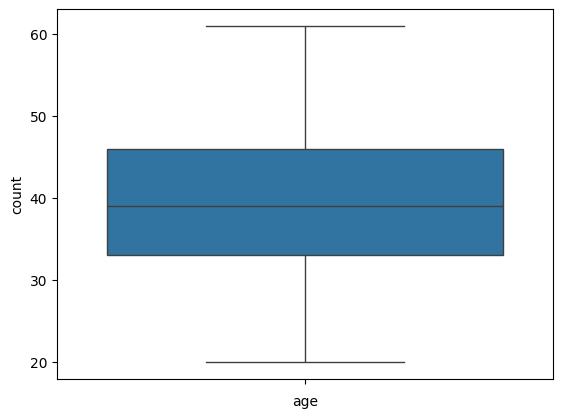

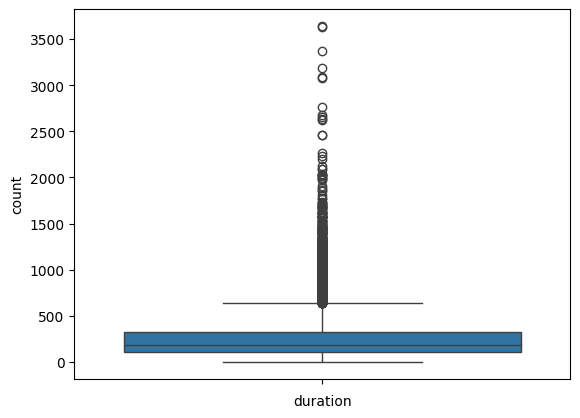

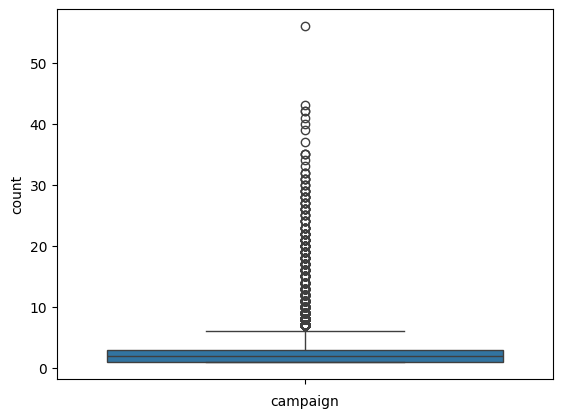

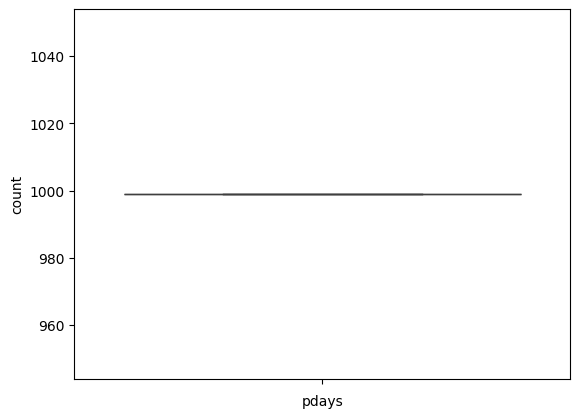

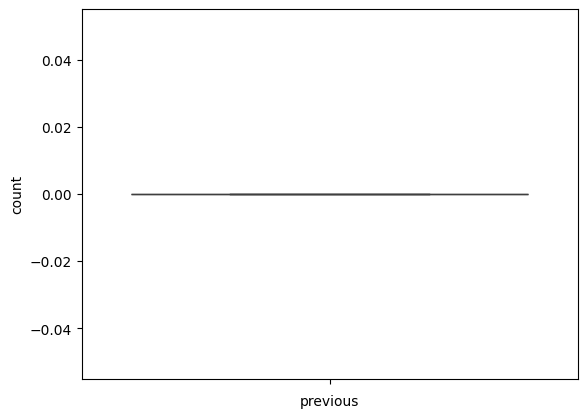

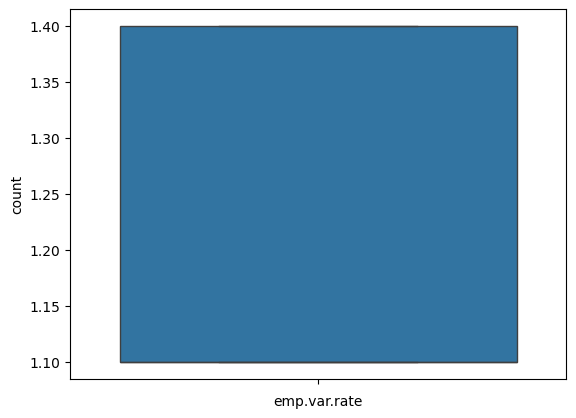

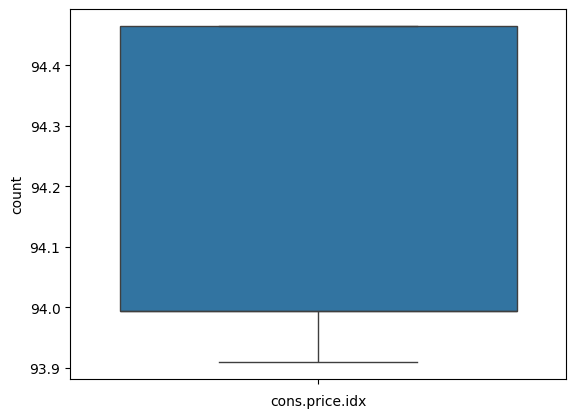

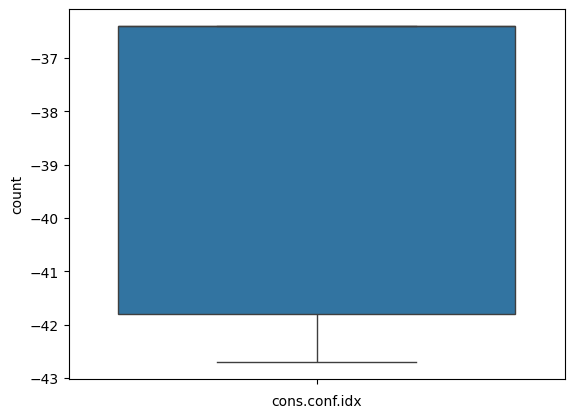

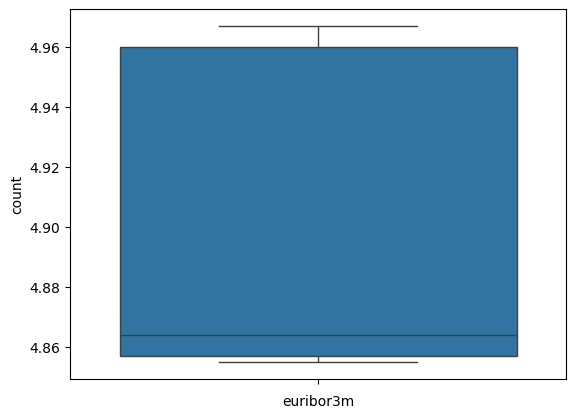

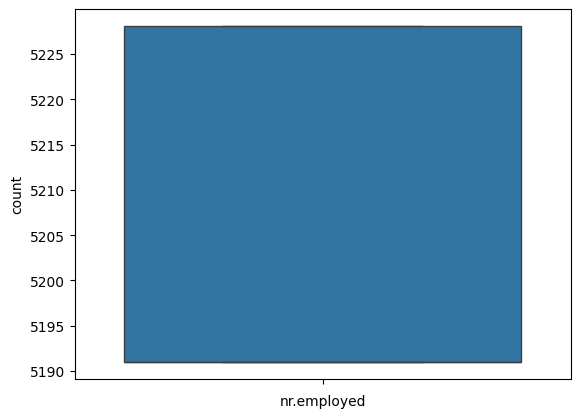

In [16]:
import seaborn as sns

for col_name in col:
  if (data[col_name].dtype !='object'):
    sns.boxplot(data[col_name])
    plt.xlabel(col_name)
    plt.ylabel('count')
    plt.show()


In [17]:
import plotly.express as px
num_col= data.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col_name in num_col:
  fig= px.box(data, y=col_name)
  fig.update_layout(xaxis_title=col_name, yaxis_title='count')
  fig.show()

In [18]:
import plotly.express as px
num_col= data.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col_name in num_col:
  fig= px.box(data, col_name)
  fig.update_layout(xaxis_title=col_name, yaxis_title='count')
  fig.show()

In [19]:
num_col=data.select_dtypes(include=['int64', 'float64'])
num_col

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...
14765,49,92,1,999,0,1.4,93.918,-42.7,4.957,5228.1
14766,49,284,1,999,0,1.4,93.918,-42.7,4.957,5228.1
14767,34,130,1,999,0,1.4,93.918,-42.7,4.957,5228.1
14768,27,151,4,999,0,1.4,93.918,-42.7,4.957,5228.1


In [20]:
for col in num_col:
  print(col)
  print(data[col].skew())

age
0.33869979059685873
duration
3.241531687247614
campaign
4.839246905264507
pdays
0.0
previous
0.0
emp.var.rate
0.10251444218375563
cons.price.idx
0.8412394470360653
cons.conf.idx
-0.1359390528904635
euribor3m
0.4686387780095858
nr.employed
0.10265736960916066


domain

rescalling

chi square testing---> helps to select features (feature selection)

ith reference to the above plot we can observe that some columns are having outliers . So what actually outliers are ,The values greater than upper limit and values lesser than lower limit .

Consider for age column where 1st quantile /25th percentile value(Q1) and 3rd quantile /75th percentile value(Q3)values are data.age.quantile(.25),data.age.quantile(.75)=(32.0, 47.0)

With the help of Q1 and Q3 we will be finding out Inter Quantile Range (IQR) for Outlier analysis

Lets start with age column

1.age

There are outliers

2.duration

There are outliers

3.campaign

There are outliers

4.pdays

There are no outliers

5.previous

There are no outliers

6.emp.var.rate

There are no outliers

7.cons.price.idx

There are no outliers

8.cons.conf.idx

There are outliers

9.nr.employed

There are no outliers

so from above inference only 4 columns as outliers those are 'age','duration','campaign','cons.conf.idx' . So in next step we'll be handling it,



#IQR method
Now with the IQR method we will be removing the outlier

The interquartile range is calculated in much the same way as the range. All you do to find it is subtract the first quartile from the third quartile: IQR = Q3 – Q1. The interquartile range shows how the data is spread about the median

(data >= Q1 - 1.5IQR) & (data <= Q3 + 1.5IQR)

Where 1.5 is standard range set to check the outliers

So with the help of above formula and IQR value we can remove the outliers ,to remove the outliers we have to calculate the values within upper and lower limit

IQR=Q3-Q1

lower limit=Q1-1.5IQR upper limit=Q3+1.5IQR

so consider for age column

Q1 = data.age.quantile(0.25) Q3 = data.age.quantile(0.75) IQR = Q3 - Q1 print(Q1-1.5IQR,Q3+1.5IQR)

(9.5 , 69.5)

so we'll consider values between (9.5 , 69.5) and rest all values will be outliers.

Same follows for all 4 ('age','duration','campaign','cons.conf.idx' ) columns.

In [21]:
#handling outliers

col_names=['age','duration','campaign','cons.conf.idx']

q1=data.age.quantile(0.25)
q3=data.age.quantile(0.75)
IQR=q3-q1
data=data[(data.age >= q1-1.5*IQR) & (data.age <= q3+1.5*IQR)]

q1=data.duration .quantile(0.25)
q3=data.duration .quantile(0.75)
IQR=q3-q1
data=data[(data.duration >= q1-1.5*IQR) & (data.duration <= q3+1.5*IQR)]

q1=data.campaign .quantile(0.25)
q3=data.campaign .quantile(0.75)
IQR=q3-q1
data=data[(data.campaign >= q1-1.5*IQR) & (data.campaign <= q3+1.5*IQR)]

q1=data['cons.conf.idx'] .quantile(0.25)
q3=data['cons.conf.idx'] .quantile(0.75)
IQR=q3-q1
data=data[(data['cons.conf.idx'] >= q1-1.5*IQR) & (data['cons.conf.idx']<= q3+1.5*IQR)]

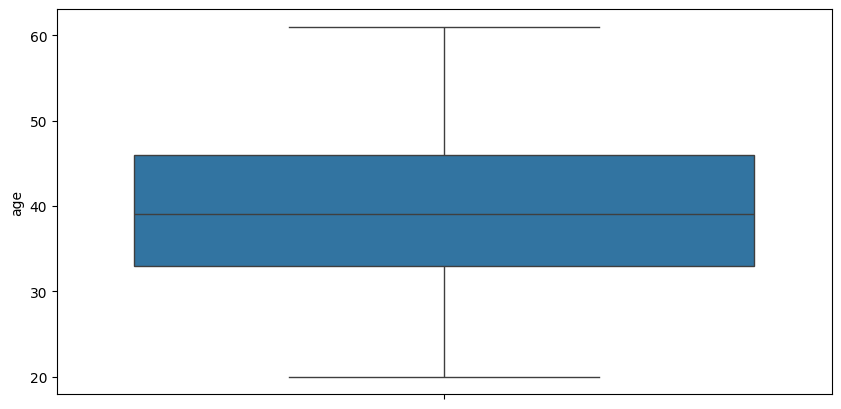

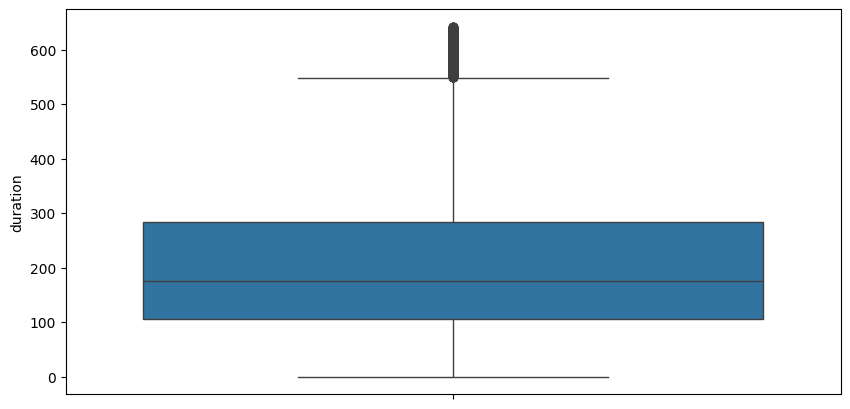

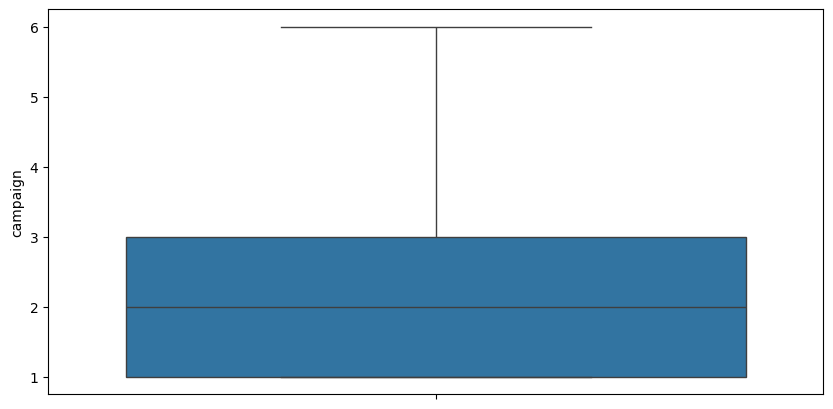

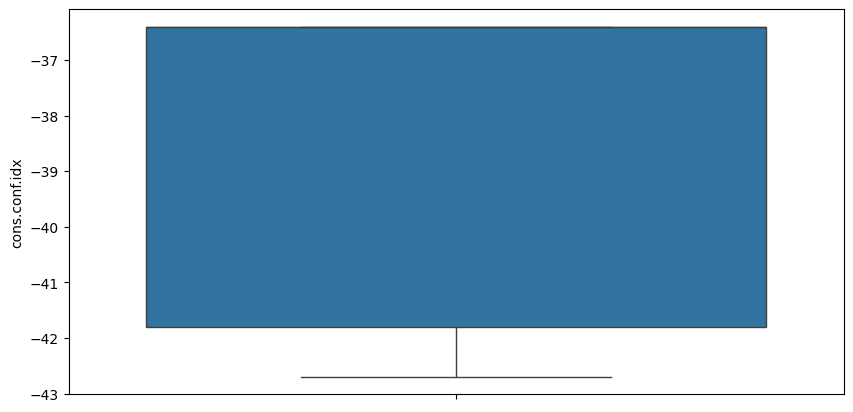

In [22]:
for col in col_names:
  plt.figure(figsize=(10,5))
  sns.boxplot(data[col])
  plt.show()

In [23]:
data.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [24]:
data.y.value_counts()

,count
y,
no,12645
yes,138


In [25]:
data['y'] = np.where(data['y'] == 'yes', 1, 0)

In [26]:
data['y']= data['y'].astype(str)

In [27]:
data.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [28]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

#1.Chi-Square test
Chi-Square test is normally done on Categorical data(object) ,where we will select each independent attribute and calculating chi-Square statistics value with the help of observed value and expected value.

if observed and expected values are close then we'll have high chi-square statistics.(high chi-square stats implies attributes are highly independent) if observed and expected values are far then we'll have less chi-square statistics.(less chi-square stats implies attributes are not independent)

With the above concept we'll set null and alternative hypothesis and check for its acceptance or rejection through p-value and alpha value (significance value)

if p -value > alpha value ,we reject null hypothesis if p-value < alpha value ,we accept null hypothesis

from scipy.stats import chisquare import scipy.stats from scipy.stats import chi2#from scipy import stats from scipy.stats import chi2_contingency

###Chisq Test for Independence

dataset_table=pd.crosstab(data['age'],data['y']) print(dataset_table)

In [29]:
from scipy.stats import chisquare
from scipy.stats import chi2
from scipy import stats
from scipy.stats import chi2_contingency

In [30]:
dataset_table=pd.crosstab(data['age'],data['y'])
print(dataset_table)

y      0   1
age         
20     6   0
21     6   0
22    22   0
23    39   0
24   106   2
25   197   2
26   227   4
27   256   4
28   365   1
29   372   4
30   474   4
31   504  12
32   490   5
33   513   5
34   497   6
35   587   7
36   573   3
37   482   4
38   488   8
39   518   9
40   448   5
41   474   4
42   433   2
43   388   2
44   335   0
45   379   3
46   340   3
47   314   3
48   298   3
49   288   1
50   275   5
51   252   3
52   265   4
53   210   1
54   192   2
55   204   2
56   228   3
57   210   4
58   160   3
59   135   3
60    94   2
61     1   0


In [31]:
from scipy.stats import chisquare
import scipy.stats
from scipy.stats import chi2
#from scipy import stats
from scipy.stats import chi2_contingency

###Chisq Test for Independence
dataset_table=pd.crosstab(data['age'],data['y'])
print(dataset_table)

y      0   1
age         
20     6   0
21     6   0
22    22   0
23    39   0
24   106   2
25   197   2
26   227   4
27   256   4
28   365   1
29   372   4
30   474   4
31   504  12
32   490   5
33   513   5
34   497   6
35   587   7
36   573   3
37   482   4
38   488   8
39   518   9
40   448   5
41   474   4
42   433   2
43   388   2
44   335   0
45   379   3
46   340   3
47   314   3
48   298   3
49   288   1
50   275   5
51   252   3
52   265   4
53   210   1
54   192   2
55   204   2
56   228   3
57   210   4
58   160   3
59   135   3
60    94   2
61     1   0


In [32]:
#observed values

observed_val=dataset_table.values
print("observed values :- \n", observed_val)

observed values :- 
 [[  6   0]
 [  6   0]
 [ 22   0]
 [ 39   0]
 [106   2]
 [197   2]
 [227   4]
 [256   4]
 [365   1]
 [372   4]
 [474   4]
 [504  12]
 [490   5]
 [513   5]
 [497   6]
 [587   7]
 [573   3]
 [482   4]
 [488   8]
 [518   9]
 [448   5]
 [474   4]
 [433   2]
 [388   2]
 [335   0]
 [379   3]
 [340   3]
 [314   3]
 [298   3]
 [288   1]
 [275   5]
 [252   3]
 [265   4]
 [210   1]
 [192   2]
 [204   2]
 [228   3]
 [210   4]
 [160   3]
 [135   3]
 [ 94   2]
 [  1   0]]


In [33]:
expected_val=chi2_contingency(dataset_table)
expected_val

Chi2ContingencyResult(statistic=np.float64(34.123855742718995), pvalue=np.float64(0.7678289212933038), dof=41, expected_freq=array([[5.93522647e+00, 6.47735273e-02],
       [5.93522647e+00, 6.47735273e-02],
       [2.17624971e+01, 2.37502934e-01],
       [3.85789721e+01, 4.21027928e-01],
       [1.06834077e+02, 1.16592349e+00],
       [1.96851678e+02, 2.14832199e+00],
       [2.28506219e+02, 2.49378080e+00],
       [2.57193147e+02, 2.80685285e+00],
       [3.62048815e+02, 3.95118517e+00],
       [3.71940859e+02, 4.05914105e+00],
       [4.72839709e+02, 5.16029101e+00],
       [5.10429477e+02, 5.57052335e+00],
       [4.89656184e+02, 5.34381601e+00],
       [5.12407885e+02, 5.59211453e+00],
       [4.97569819e+02, 5.43018071e+00],
       [5.87587421e+02, 6.41257921e+00],
       [5.69781741e+02, 6.21825862e+00],
       [4.80753344e+02, 5.24665571e+00],
       [4.90645388e+02, 5.35461159e+00],
       [5.21310725e+02, 5.68927482e+00],
       [4.48109599e+02, 4.89040131e+00],
       [4.7283

In [34]:
observed_value=[[1,15],
                [20,25]]

chi2, p, dof, expected = chi2_contingency(observed=observed_value)

In [35]:
print(expected)

[[ 5.50819672 10.49180328]
 [15.49180328 29.50819672]]


In [36]:
print(f'p-value :  {p}')

p-value :  0.014069328699933156


In [37]:
"""# prompt: could u give the code for chi2 testing for age and y

# Assuming 'data' DataFrame is already loaded and preprocessed as in the provided code.

# Example using 'job' and 'y'
dataset_table = pd.crosstab(data['job'], data['y'])
observed_val = dataset_table.values
chi2, p, dof, expected = chi2_contingency(observed=observed_val)
print(f"Chi2 test for 'job' and 'y':")
print(f"Chi2 statistic: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of freedom: {dof}")
print(f"Expected values:\n{expected}")


# Example using 'age' and 'y' (Requires binning 'age' as it's numerical)
# Binning age into categories (example: 20-30, 31-40, etc.)
data['age_group'] = pd.cut(data['age'], bins=range(0, 101, 10))  # Adjust bins as needed
dataset_table = pd.crosstab(data['age_group'], data['y'])
observed_val = dataset_table.values
chi2, p, dof, expected = chi2_contingency(observed=observed_val)
print(f"\nChi2 test for 'age_group' and 'y':")
print(f"Chi2 statistic: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of freedom: {dof}")
print(f"Expected values:\n{expected}")"""


'# prompt: could u give the code for chi2 testing for age and y\n\n# Assuming \'data\' DataFrame is already loaded and preprocessed as in the provided code.\n\n# Example using \'job\' and \'y\'\ndataset_table = pd.crosstab(data[\'job\'], data[\'y\'])\nobserved_val = dataset_table.values\nchi2, p, dof, expected = chi2_contingency(observed=observed_val)\nprint(f"Chi2 test for \'job\' and \'y\':")\nprint(f"Chi2 statistic: {chi2}")\nprint(f"P-value: {p}")\nprint(f"Degrees of freedom: {dof}")\nprint(f"Expected values:\n{expected}")\n\n\n# Example using \'age\' and \'y\' (Requires binning \'age\' as it\'s numerical)\n# Binning age into categories (example: 20-30, 31-40, etc.)\ndata[\'age_group\'] = pd.cut(data[\'age\'], bins=range(0, 101, 10))  # Adjust bins as needed\ndataset_table = pd.crosstab(data[\'age_group\'], data[\'y\'])\nobserved_val = dataset_table.values\nchi2, p, dof, expected = chi2_contingency(observed=observed_val)\nprint(f"\nChi2 test for \'age_group\' and \'y\':")\nprint(f"

In [39]:
Expected_Values=expected_val[3]
Expected_Values

array([[5.93522647e+00, 6.47735273e-02],
       [5.93522647e+00, 6.47735273e-02],
       [2.17624971e+01, 2.37502934e-01],
       [3.85789721e+01, 4.21027928e-01],
       [1.06834077e+02, 1.16592349e+00],
       [1.96851678e+02, 2.14832199e+00],
       [2.28506219e+02, 2.49378080e+00],
       [2.57193147e+02, 2.80685285e+00],
       [3.62048815e+02, 3.95118517e+00],
       [3.71940859e+02, 4.05914105e+00],
       [4.72839709e+02, 5.16029101e+00],
       [5.10429477e+02, 5.57052335e+00],
       [4.89656184e+02, 5.34381601e+00],
       [5.12407885e+02, 5.59211453e+00],
       [4.97569819e+02, 5.43018071e+00],
       [5.87587421e+02, 6.41257921e+00],
       [5.69781741e+02, 6.21825862e+00],
       [4.80753344e+02, 5.24665571e+00],
       [4.90645388e+02, 5.35461159e+00],
       [5.21310725e+02, 5.68927482e+00],
       [4.48109599e+02, 4.89040131e+00],
       [4.72839709e+02, 5.16029101e+00],
       [4.30303919e+02, 4.69608073e+00],
       [3.85789721e+02, 4.21027928e+00],
       [3.313834

In [41]:
a=zip(observed_val,Expected_Values)

In [42]:
a

In [43]:
chi_square=sum([(o-e)**2./e for o,e in a])
chi_square_statistic=chi_square[0]+chi_square[1]
chi_square_statistic

np.float64(34.123855742718995)

In [44]:
no_of_rows=len(dataset_table.iloc[0:2,0])
no_of_columns=len(dataset_table.iloc[0,0:2])
ddof=(no_of_rows-1)*(no_of_columns-1)
print("Degree of Freedom:-",ddof)

Degree of Freedom:- 1


In [45]:
#ex(zip_)
list1=[1,2,3]
list2=['a','b','c']
zipped=zip(list1,list2)
for item in zipped:
  print(item)

(1, 'a')
(2, 'b')
(3, 'c')


In [46]:

alpha = 0.05
print("chi-square statistic:-",chi_square_statistic)

chi-square statistic:- 34.123855742718995


In [47]:
critical_value=scipy.stats.chi2.ppf(q=1-alpha,df=ddof)
print('critical_value:',critical_value)

critical_value: 3.841458820694124


In [49]:
#p-value
# Instead of chi2, use scipy.stats.chi2 for the cdf function
p_value = 1 - scipy.stats.chi2.cdf(x=chi_square_statistic, df=ddof)
print('p-value:', p_value)
print('Significance level: ', alpha)
print('Degree of Freedom: ', ddof)

p-value: 5.171338246512391e-09
Significance level:  0.05
Degree of Freedom:  1


In [50]:

di={'Age':p_value}
df=pd.DataFrame()
df.append(di,ignore_index=True)

AttributeError: 'DataFrame' object has no attribute 'append'